In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import (
    CannonModel,
    fit_labels_batch,
    _build_cannon_design_matrix,  # TODO(audit-H7): replace with public wrapper
)
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone  # TODO(audit-H8): replace with public wrapper

import plotters

In [2]:
# Load training spectra and cannon model
spec_data = np.load("training_spectra.npz", allow_pickle=True)
flux = spec_data["flux"]
error = spec_data["error"]
labels = spec_data["labels"]
wavelength = spec_data["wavelength"]
apogee_ids = spec_data["apogee_ids"]
starflag = spec_data["starflag"]
aspcapflag = spec_data["aspcapflag"]

model_data = np.load("cannon_model.npz", allow_pickle=True)
train_idx = model_data["train_idx"]
cv_idx = model_data["cv_idx"]

model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)

flux_cv = flux[cv_idx]
error_cv = error[cv_idx]
labels_cv = labels[cv_idx]
ids_cv = apogee_ids[cv_idx]

print(f"Cannon model: chi2_r = {model.chi2_r:.3f}")
print(f"CV set: {len(cv_idx)} stars")

Cannon model: chi2_r = 0.998
CV set: 944 stars


## Problem 9 — Cross-Validation

### Why cross-validation?

The Cannon's coefficients $\boldsymbol{\theta}_\lambda$ were optimized to minimize the training residuals on the 943 stars in the *training* split (NB 02). By construction, those training residuals are an upper-bound-optimistic estimate of model accuracy: any honest assessment of how well the Cannon will perform on a *new* spectrum (e.g., the mystery star in NB 04) must use stars the model has never seen.

We hold out the other half of the post-cut sample — the 943-star *cross-validation (CV) set* — and use the trained model to fit labels for each CV star independently, then compare those Cannon-fitted labels to the ASPCAP reference labels. The bias and scatter of the residuals (`fitted − ASPCAP`) on this held-out set are the figures of merit reported throughout the rest of the lab.

### Fit labels on the CV set

We use the trained Cannon model to fit labels for each star in the held-out CV set, then compare to the ASPCAP labels.

In [3]:
fitted_labels = fit_labels_batch(model, flux_cv, error_cv)
print(f"Fitted labels shape: {fitted_labels.shape}")

Fitting labels:   0%|          | 0/944 [00:00<?, ?it/s]

Fitted labels shape: (944, 5)


### 1-to-1 label recovery

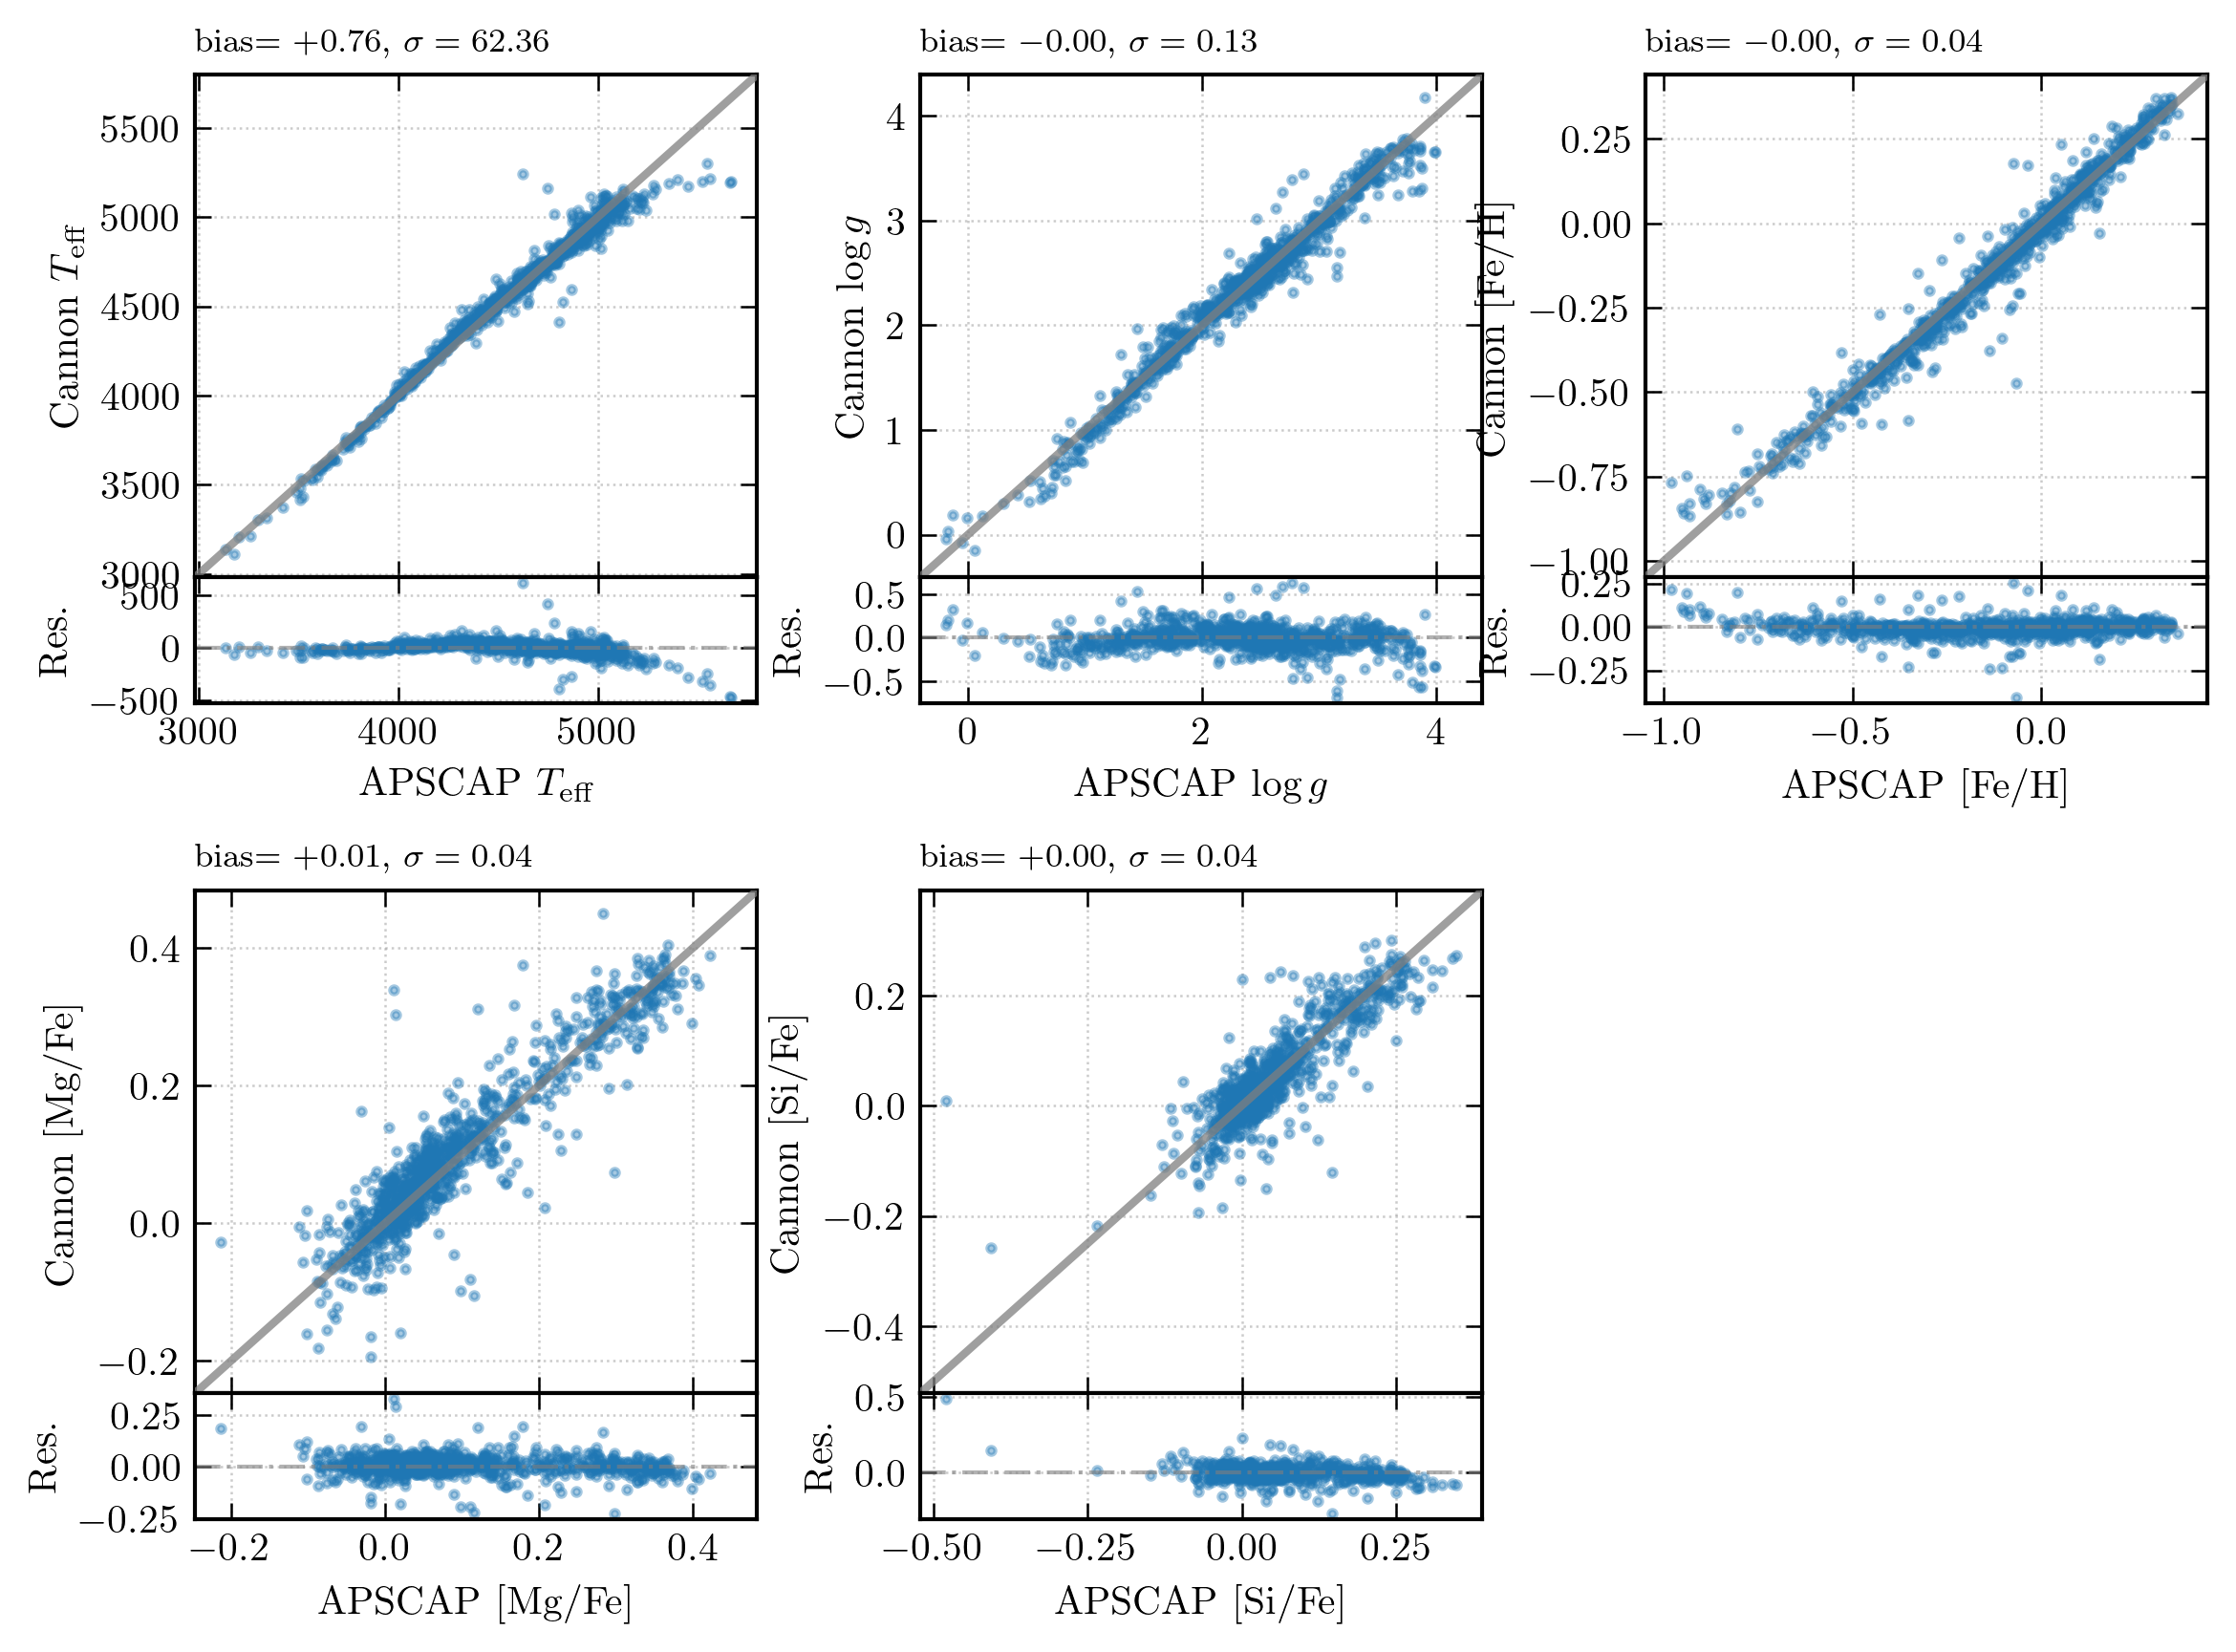

In [4]:
axes = plotters.plot_label_recovery(labels_cv, fitted_labels, LABEL_LATEX)
plt.show()

In [5]:
# Numeric CV metrics: bias, scatter, RMS, and 3-sigma outlier counts per label.
# This DataFrame is the canonical CV-metrics table referenced by NB 06 and the report.
cv_residuals = fitted_labels - labels_cv
cv_bias = np.mean(cv_residuals, axis=0)
cv_scatter = np.std(cv_residuals, axis=0)
cv_rms = np.sqrt(np.mean(cv_residuals ** 2, axis=0))
cv_n_outliers = np.sum(np.abs(cv_residuals) > 3 * cv_scatter[None, :], axis=0)

cv_metrics = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Bias": cv_bias,
    "Scatter (std)": cv_scatter,
    "RMS": cv_rms,
    "n_outliers (|Δ|>3σ)": cv_n_outliers,
})
cv_metrics


,Label,Bias,Scatter (std),RMS,n_outliers (|Δ|>3σ)
0,TEFF,0.763331,62.361370,62.366042,15
1,LOGG,-0.004459,0.127592,0.127669,17
2,FE_H,-0.003880,0.044781,0.044949,23
3,MG_FE,0.008370,0.044697,0.045474,19
4,SI_FE,0.000840,0.044293,0.044301,15


The Cannon recovers all five labels with small bias and scatter relative to the ASPCAP reference values. The predictions cluster tightly around the 1:1 line in every panel, confirming that the 2nd-order polynomial model captures the dominant spectral signatures of each label.

Some labels agree better than others:

- **$[\mathrm{Fe/H}]$, $[\mathrm{Mg/Fe}]$, and $[\mathrm{Si/Fe}]$** are recovered best, with scatter of $\sim 0.04$–$0.05$ dex — comparable to the ASPCAP pipeline's own internal precision. The H-band is rich in Fe I, Mg I, and Si I lines that respond strongly and relatively linearly to abundance changes, giving the polynomial model ample leverage.
- **$\log g$** has scatter $\sim 0.13$ dex. Surface gravity affects spectra more subtly (primarily through pressure broadening and molecular equilibrium shifts), and the training set spans a narrower dynamic range in $\log g$ than in $T_{\rm eff}$, reducing the signal-to-noise of the gradient.
- **$T_{\rm eff}$** has the largest absolute scatter ($\sim 59$ K) but is still $< 2\%$ of the label range ($\sim 3000$–$5500$ K). The dominant effect of temperature — reshaping the entire spectral energy distribution — is well captured by the polynomial. The residuals show slight structure at the cool end ($T_{\rm eff} \lesssim 3800$ K), where molecular bands (CO, OH) introduce nonlinearities that the quadratic terms cannot fully absorb.

## Problem 10 — Outlier Investigation

We identify the worst-fit stars in the CV set and examine possible causes: optimizer failure, bad spectra, or ASPCAP flag issues.

In [6]:
# Identify worst-fit stars in the CV set
residuals = fitted_labels - labels_cv
label_stds_cv = np.std(labels_cv, axis=0)
label_stds_cv[label_stds_cv == 0] = 1.0
norm_resid = np.sqrt(np.sum((residuals / label_stds_cv) ** 2, axis=1))
worst_idx = np.argsort(norm_resid)[-5:][::-1]

print("Worst-fit CV stars:")
for i, idx in enumerate(worst_idx):
    print(f"  {i+1}. {ids_cv[idx]}: normalized residual = {norm_resid[idx]:.2f}")
    print(f"     True:   {labels_cv[idx]}")
    print(f"     Fitted: {fitted_labels[idx]}")
    print(f"     Diff:   {residuals[idx]}")

Worst-fit CV stars:
  1. 2M19294176+3747402: normalized residual = 6.05
     True:   [ 4.749188e+03  3.366423e+00 -8.060800e-01  9.837997e-02 -4.801394e-01]
     Fitted: [ 5.16319361e+03  3.43114618e+00 -6.09838366e-01 -9.80770540e-02
  8.87104887e-03]
     Diff:   [ 4.14005606e+02  6.47231810e-02  1.96241634e-01 -1.96457024e-01
  4.89010449e-01]
  2. 2M21281377+1054307: normalized residual = 3.61
     True:   [ 3.992648e+03  8.700104e-01 -8.343500e-01  1.400000e-02  2.695918e-04]
     Fitted: [ 4.05827920e+03  1.07371838e+00 -8.61162419e-01  3.02980154e-01
  2.28138056e-01]
     Diff:   [ 6.56311983e+01  2.03707978e-01 -2.68124193e-02  2.88980154e-01
  2.27868464e-01]
  3. 2M21344249+1214085: normalized residual = 3.61
     True:   [ 4.317790e+03  1.447118e+00 -8.243900e-01  1.091403e-02  4.496759e-02]
     Fitted: [ 4.48100961e+03  1.97172760e+00 -8.21221013e-01  3.38860668e-01
  2.31762388e-01]
     Diff:   [1.63219605e+02 5.24609601e-01 3.16898728e-03 3.27946638e-01
 1.86794798e-01

In [7]:
# Check if fitted labels ≈ initial guess (optimizer stuck at mean)
stuck_threshold = 0.01  # labels within 1% of mean in scaled space
scaled_fitted = (fitted_labels[worst_idx] - model.label_means) / model.label_stds
stuck = np.all(np.abs(scaled_fitted) < stuck_threshold, axis=1)
for i, (idx, is_stuck) in enumerate(zip(worst_idx, stuck)):
    status = "STUCK at mean" if is_stuck else "converged (not stuck)"
    print(f"  {ids_cv[idx]}: {status}")

  2M19294176+3747402: converged (not stuck)
  2M21281377+1054307: converged (not stuck)
  2M21344249+1214085: converged (not stuck)
  2M19445606+2411079: converged (not stuck)
  2M03595883+2418071: converged (not stuck)


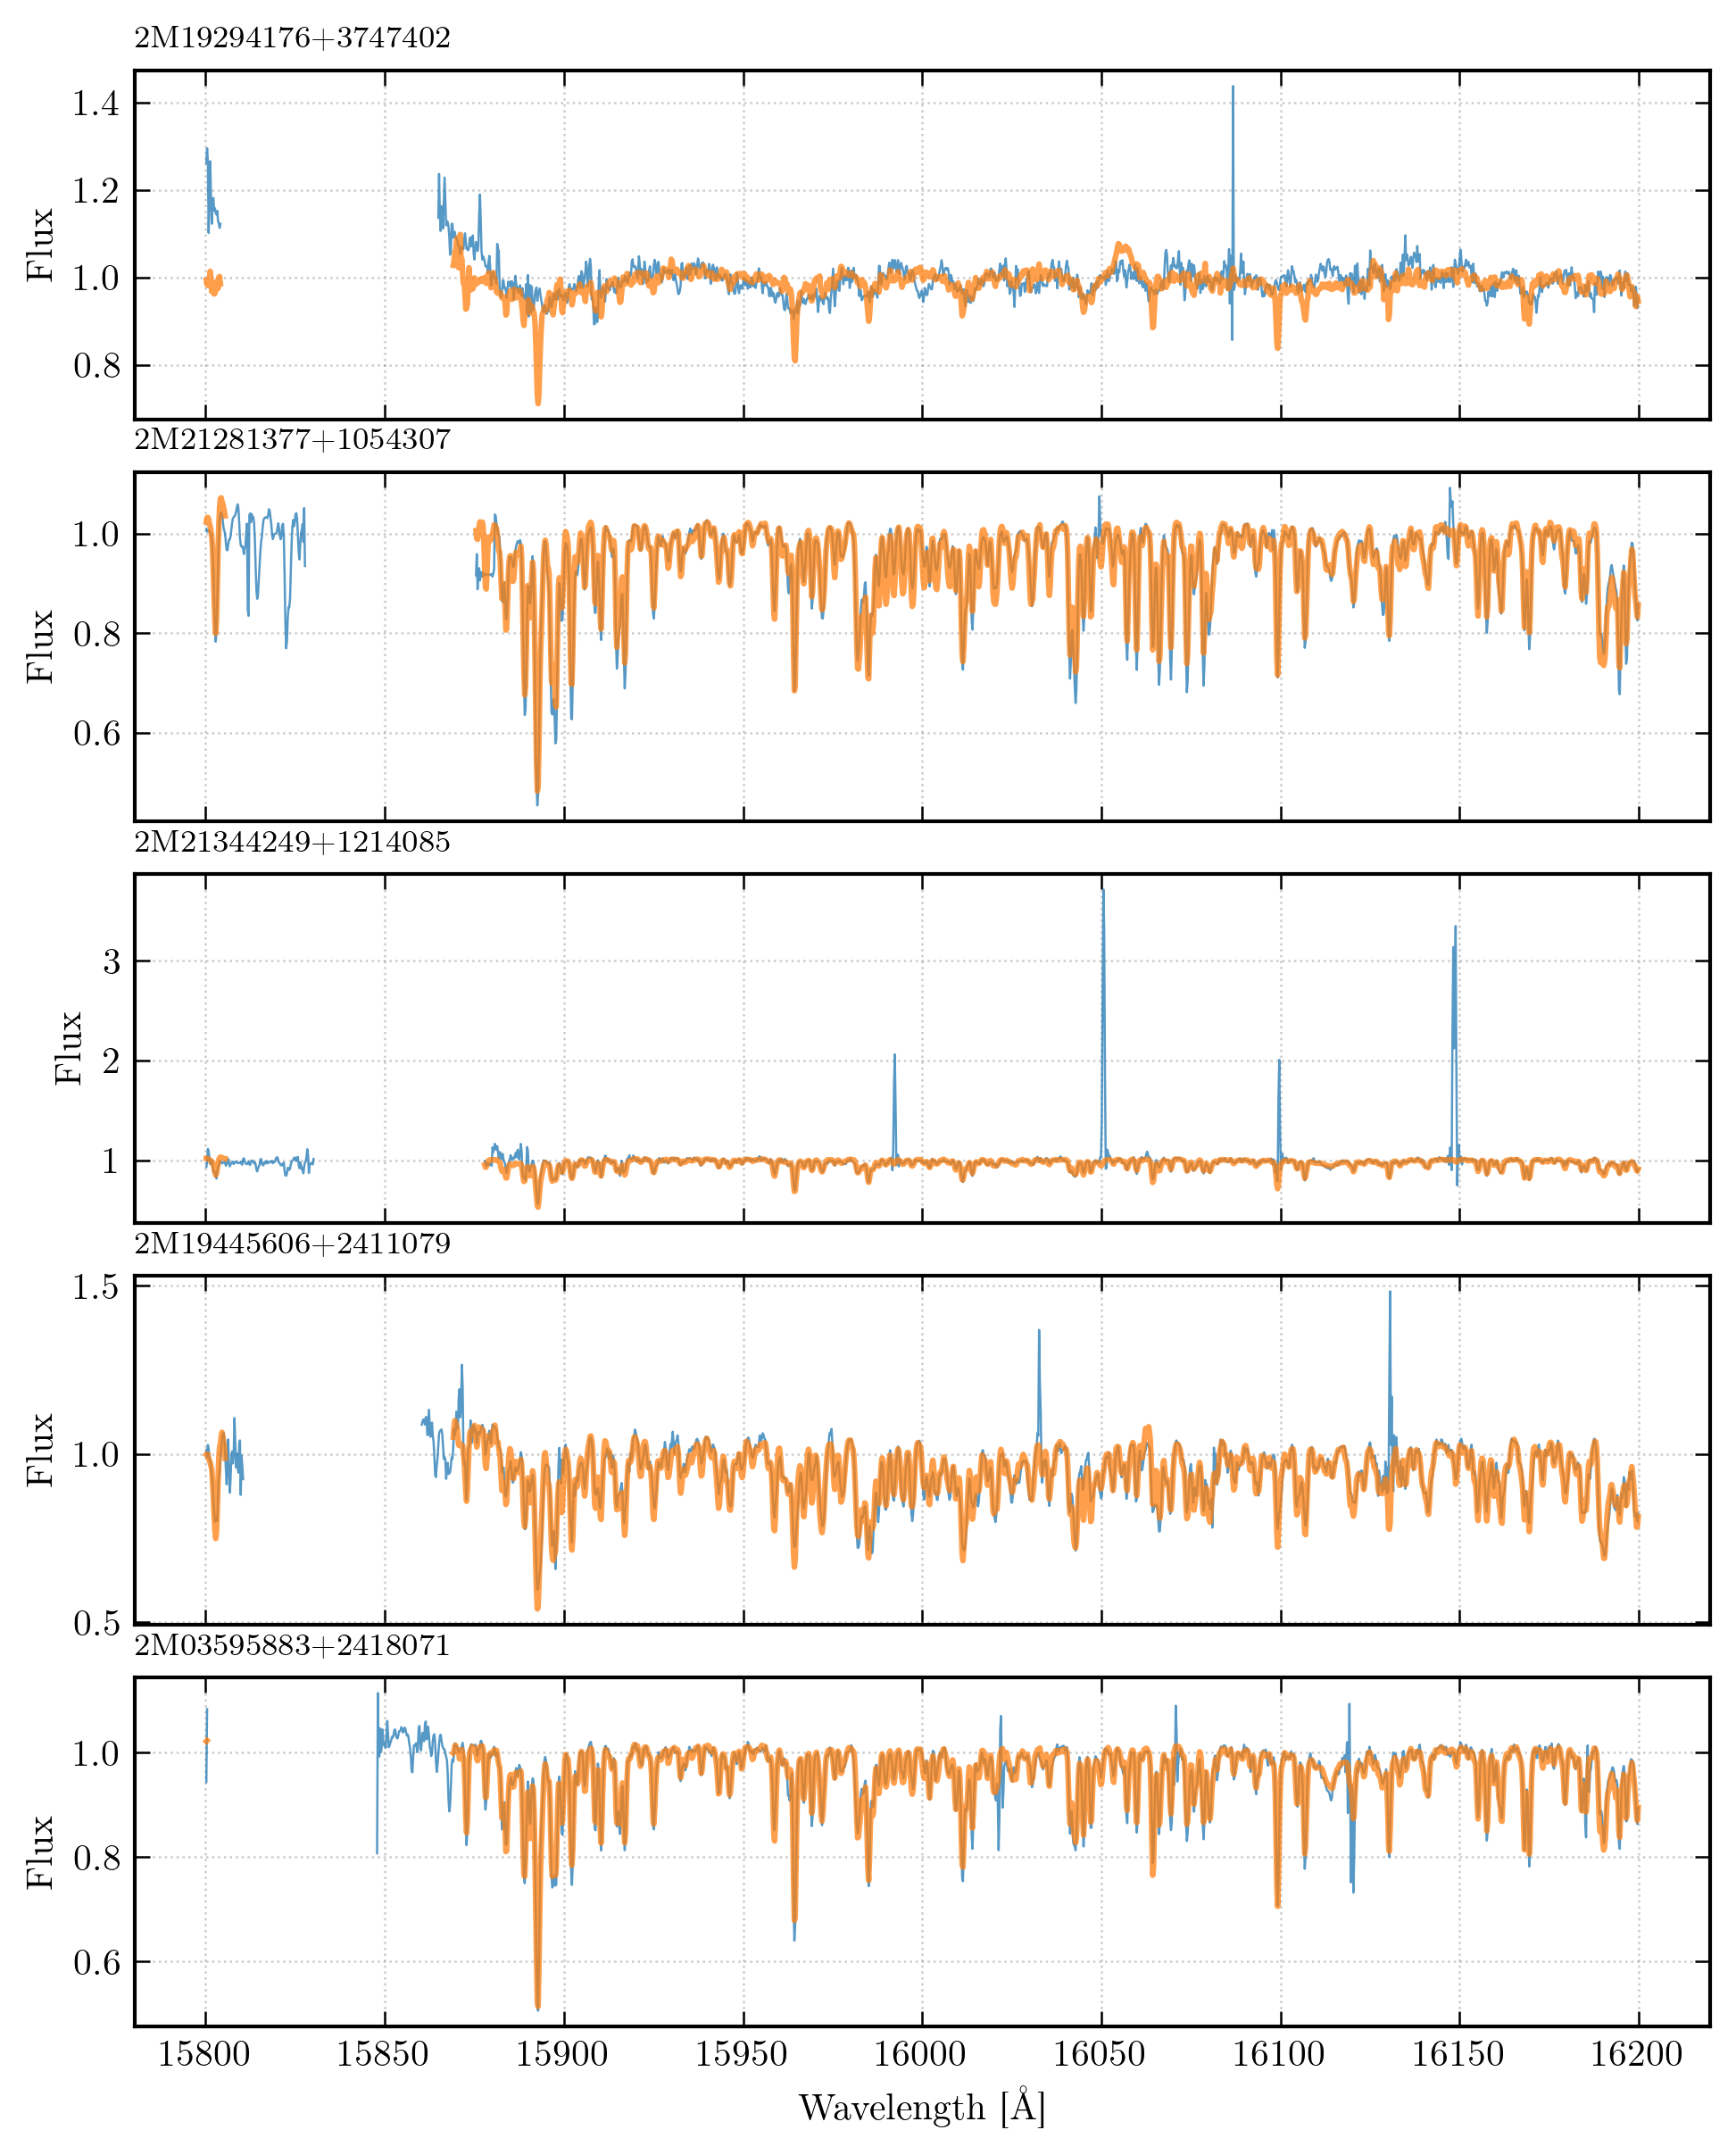

In [8]:
# Plot outlier spectra
flux_pred_worst = np.array([model.predict(fitted_labels[idx]) for idx in worst_idx])

axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst_idx], error_cv[worst_idx],
    flux_pred_worst, ids_cv[worst_idx],
    wl_min=15800, wl_max=16200,
)
plt.show()

In [9]:
# Check ASPCAP flags for outliers
print("ASPCAP flags for outlier stars:")
for idx in worst_idx:
    print(f"  {ids_cv[idx]}: starflag={starflag[cv_idx[idx]]:#010x}, "
          f"aspcapflag={aspcapflag[cv_idx[idx]]:#010x}")

ASPCAP flags for outlier stars:
  2M19294176+3747402: starflag=0x00800004, aspcapflag=0x000042c0
  2M21281377+1054307: starflag=0x00000000, aspcapflag=0x00000004
  2M21344249+1214085: starflag=0x00000200, aspcapflag=0x00000040
  2M19445606+2411079: starflag=0x00000004, aspcapflag=0x00000044
  2M03595883+2418071: starflag=0x00000000, aspcapflag=0x00000000


In [10]:
# Check continuum normalization quality for outliers
continuum_mask = spec_data["continuum_mask"].astype(bool)

print("Continuum normalization quality for outlier stars:")
print(f"  {'ID':<25s} {'Mean cont px':>12s} {'Std cont px':>12s} {'% inf err':>10s}")
for idx in worst_idx:
    f_cont = flux_cv[idx, continuum_mask]
    e_cont = error_cv[idx, continuum_mask]
    valid = np.isfinite(f_cont) & (e_cont < np.inf)
    frac_inf = 1.0 - np.sum(valid) / len(f_cont)
    if np.sum(valid) > 0:
        print(f"  {ids_cv[idx]:<25s} {np.mean(f_cont[valid]):>12.4f} "
              f"{np.std(f_cont[valid]):>12.4f} {100*frac_inf:>9.1f}%")
    else:
        print(f"  {ids_cv[idx]:<25s} {'N/A':>12s} {'N/A':>12s} {100*frac_inf:>9.1f}%")

Continuum normalization quality for outlier stars:
  ID                        Mean cont px  Std cont px  % inf err
  2M19294176+3747402              1.0067       0.1561       0.0%
  2M21281377+1054307              0.9996       0.0148       0.0%
  2M21344249+1214085              1.0300       0.2552       0.0%
  2M19445606+2411079              1.0043       0.0407       0.0%
  2M03595883+2418071              1.0000       0.0136       0.0%


### Interpreting the outlier diagnostics

The four diagnostic blocks above (worst-fit ranking, optimizer-stuckness check, ASPCAP flag inspection, continuum-quality summary) need to be read together. Three patterns typically emerge:

1. **Optimizer-stuck stars** — fitted labels lie within 1% of the training-set mean in scaled space. These are stars where the trust-region optimizer never moved off the initial guess, usually because the local likelihood gradient was indistinguishable from numerical noise (extremely low SNR, almost-all-masked spectrum, or a spectrum that does not look like any training star). The fitted labels are meaningless for these stars; the large normalized residual is real.
2. **Bad-reference stars** — the optimizer converged on a sensible solution, the spectrum looks reasonable, but the fitted labels disagree strongly with ASPCAP because the *ASPCAP* labels are themselves unreliable. These stars usually carry a non-zero `aspcapflag` (parameter rails, sigma-truncation, or rejected calibration). The Cannon's fit is in fact more trustworthy than the reference here, but for the purposes of this notebook we are using ASPCAP as ground truth, so they show up as "outliers."
3. **Bad-spectrum stars** — the spectrum has an unflagged artifact (cosmic ray, persistent detector glitch, sky-subtraction failure) or a degraded continuum normalization (mean continuum-pixel flux significantly off unity, large fraction of masked pixels). The Cannon fit is genuinely poor at the residual level, and the labels are unreliable.


Outlier stars may have non-zero `starflag` or `aspcapflag` values indicating warnings from the ASPCAP pipeline (e.g., low SNR in certain wavelength regions, unreliable abundance determinations, or issues with the RV combination of visits). Stars with significant flag bits may have less reliable ASPCAP labels, making them poor reference points for evaluating the Cannon's performance.

For continuum normalization: if the mean of continuum pixels deviates significantly from 1.0, or if the fraction of masked (`inf` error) pixels is unusually high, the normalization may have failed for that star. Poor normalization would introduce systematic biases in all fitted labels.

For stars where the optimizer converged away from the initial guess, the Cannon fit is meaningful but the ASPCAP reference labels themselves may be inaccurate.

### Per-label worst deviators

The combined normalized residual above averages across all 5 labels, potentially masking stars that are extreme outliers in a single label but acceptable in others. We now inspect the 5 worst deviators for each label individually.

Worst 5 deviators in TEFF:
  1. 2M21261328+1139054: true=4624.9, fitted=5240.2, Δ=+615.2
  2. 2M19292252+3904095: true=5669.1, fitted=5199.4, Δ=-469.7
  3. 2M03581483+2537118: true=5660.6, fitted=5193.3, Δ=-467.3
  4. 2M19294176+3747402: true=4749.2, fitted=5163.2, Δ=+414.0
  5. 2M03564068+2603202: true=4803.7, fitted=4413.9, Δ=-389.8


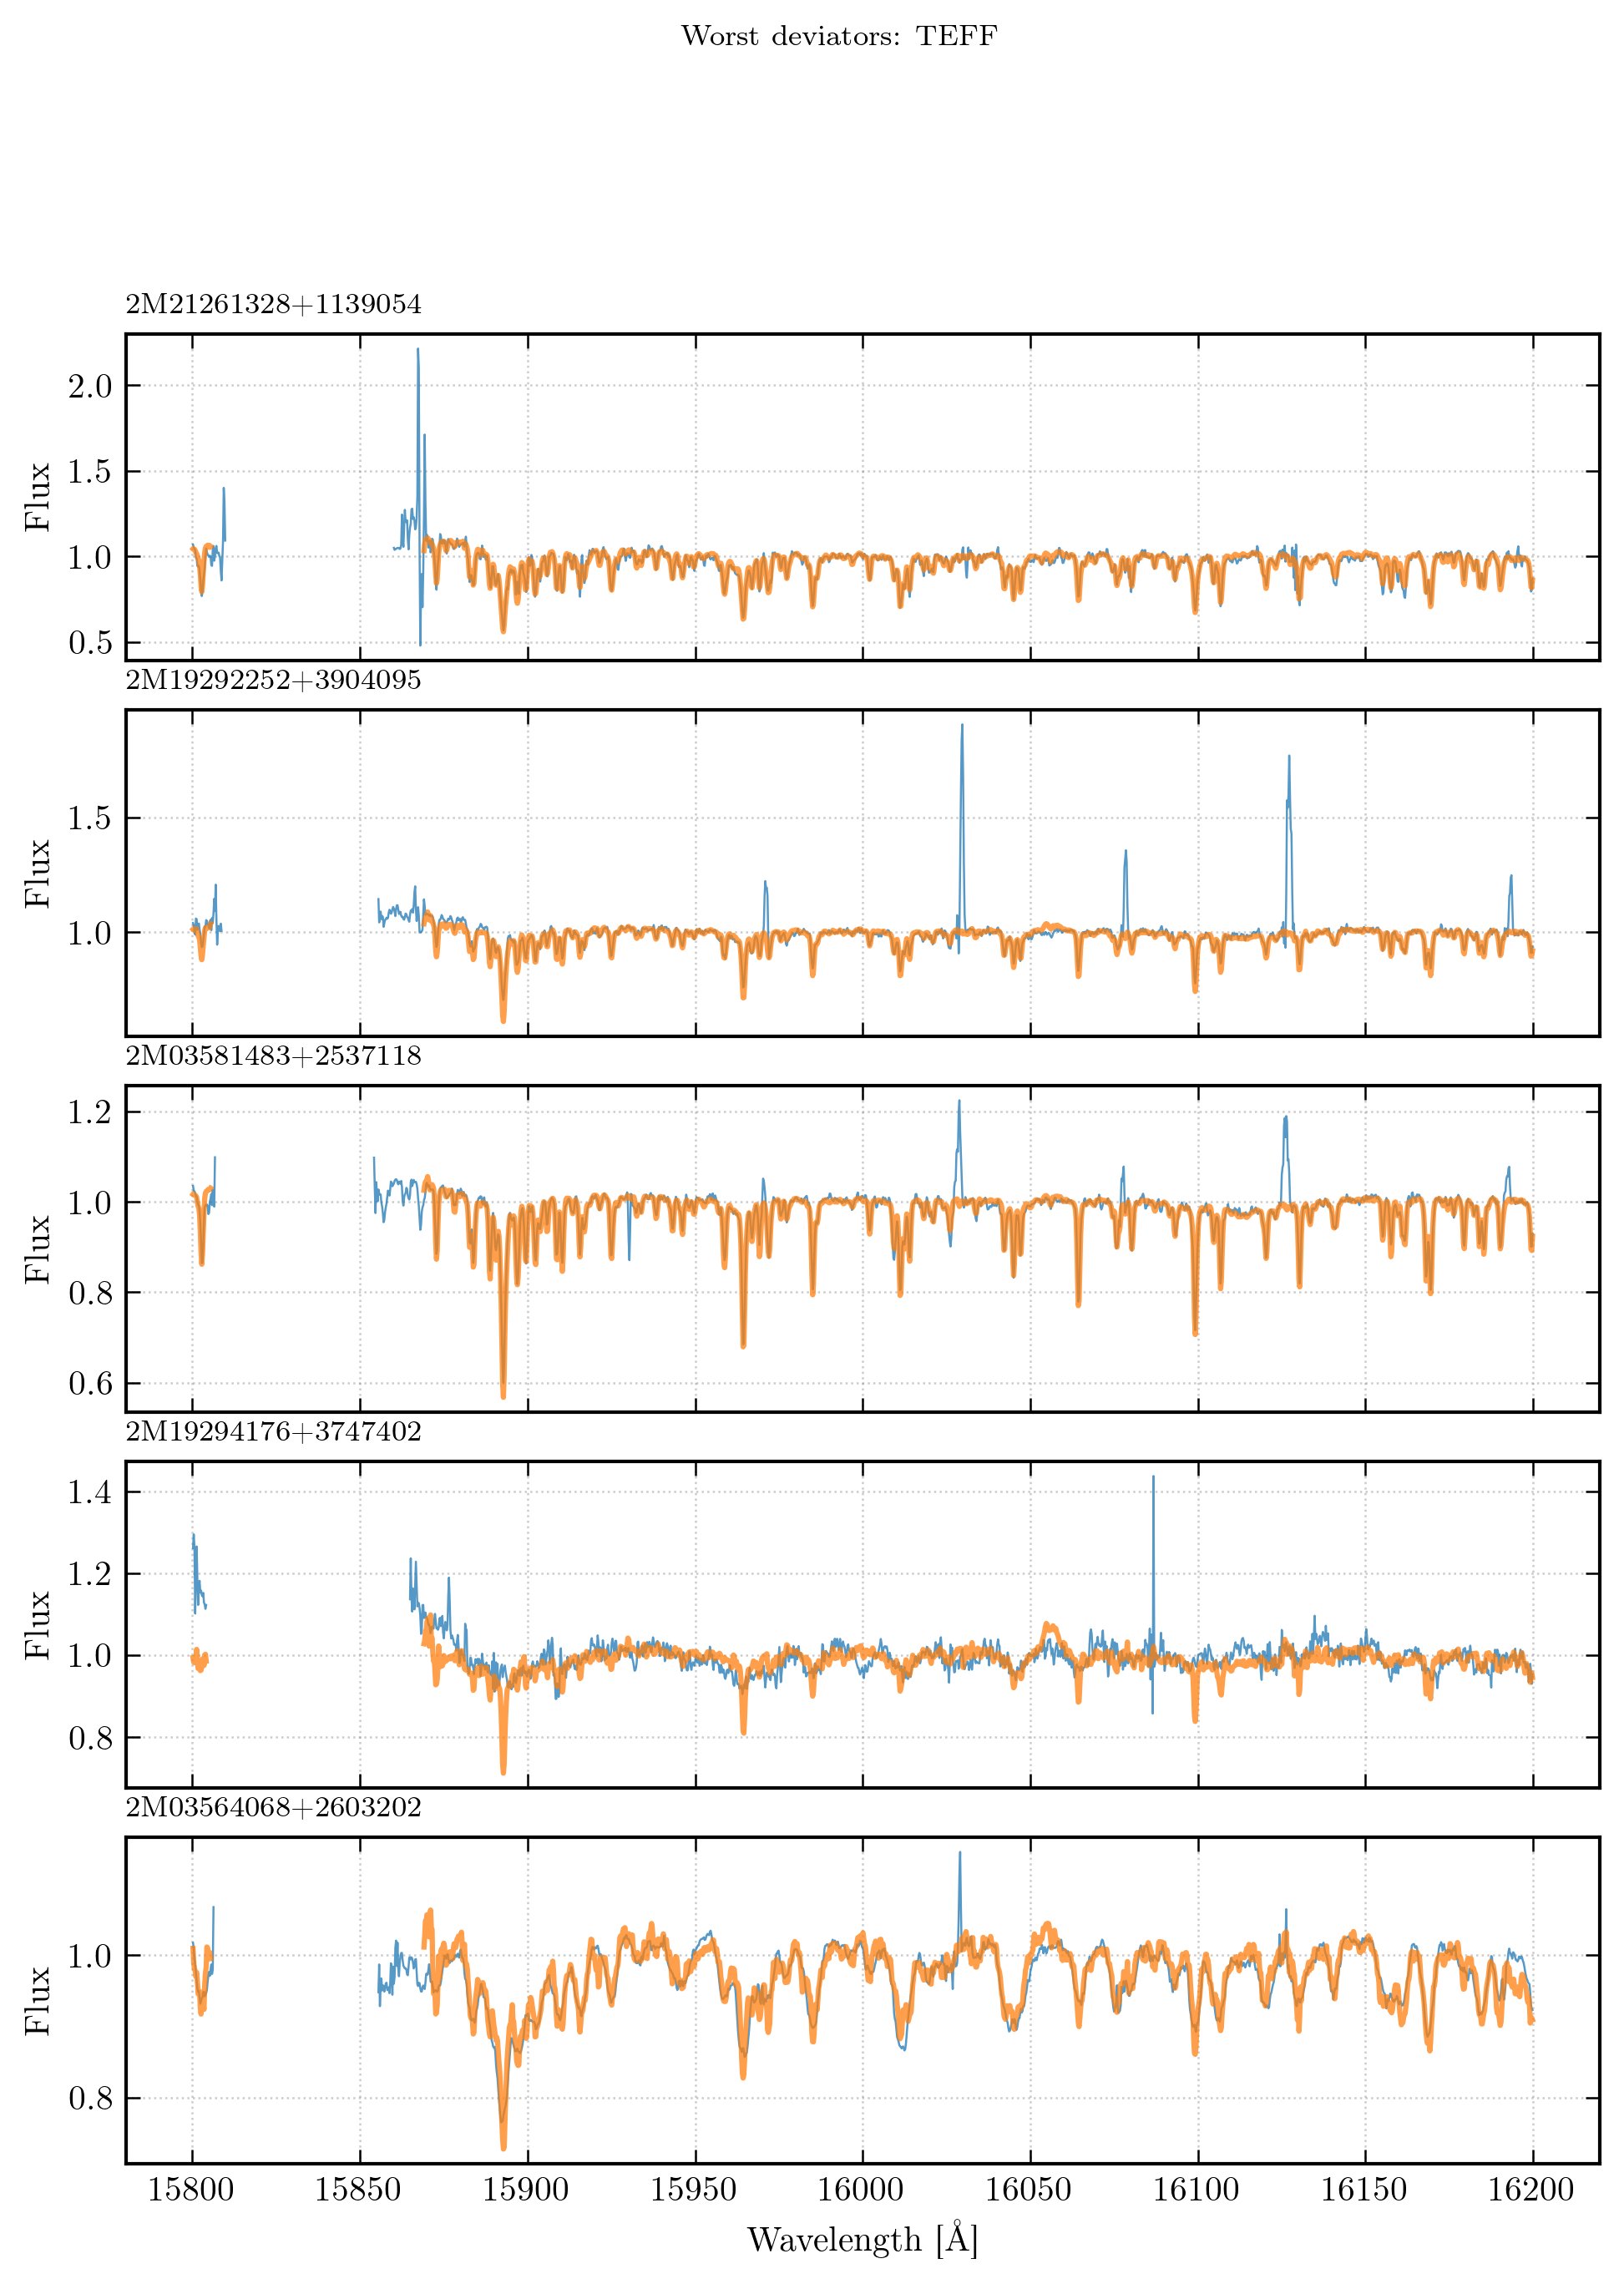

In [11]:
# Worst 5 deviators in Teff
residuals = fitted_labels - labels_cv
i_label = 0
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.1f}, "
          f"fitted={fitted_labels[idx, i_label]:.1f}, "
          f"Δ={residuals[idx, i_label]:+.1f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w, ids_cv[worst5],
    wl_min=15800, wl_max=16200,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in LOGG:
  1. 2M21280685+1157477: true=3.152, fitted=2.467, Δ=-0.684
  2. 2M03564068+2603202: true=2.767, fitted=3.393, Δ=+0.625
  3. 2M19410898+2240121: true=3.154, fitted=2.547, Δ=-0.607
  4. 2M19464751+2354171: true=2.688, fitted=3.271, Δ=+0.583
  5. 2M19401787+2418231: true=2.868, fitted=3.444, Δ=+0.576


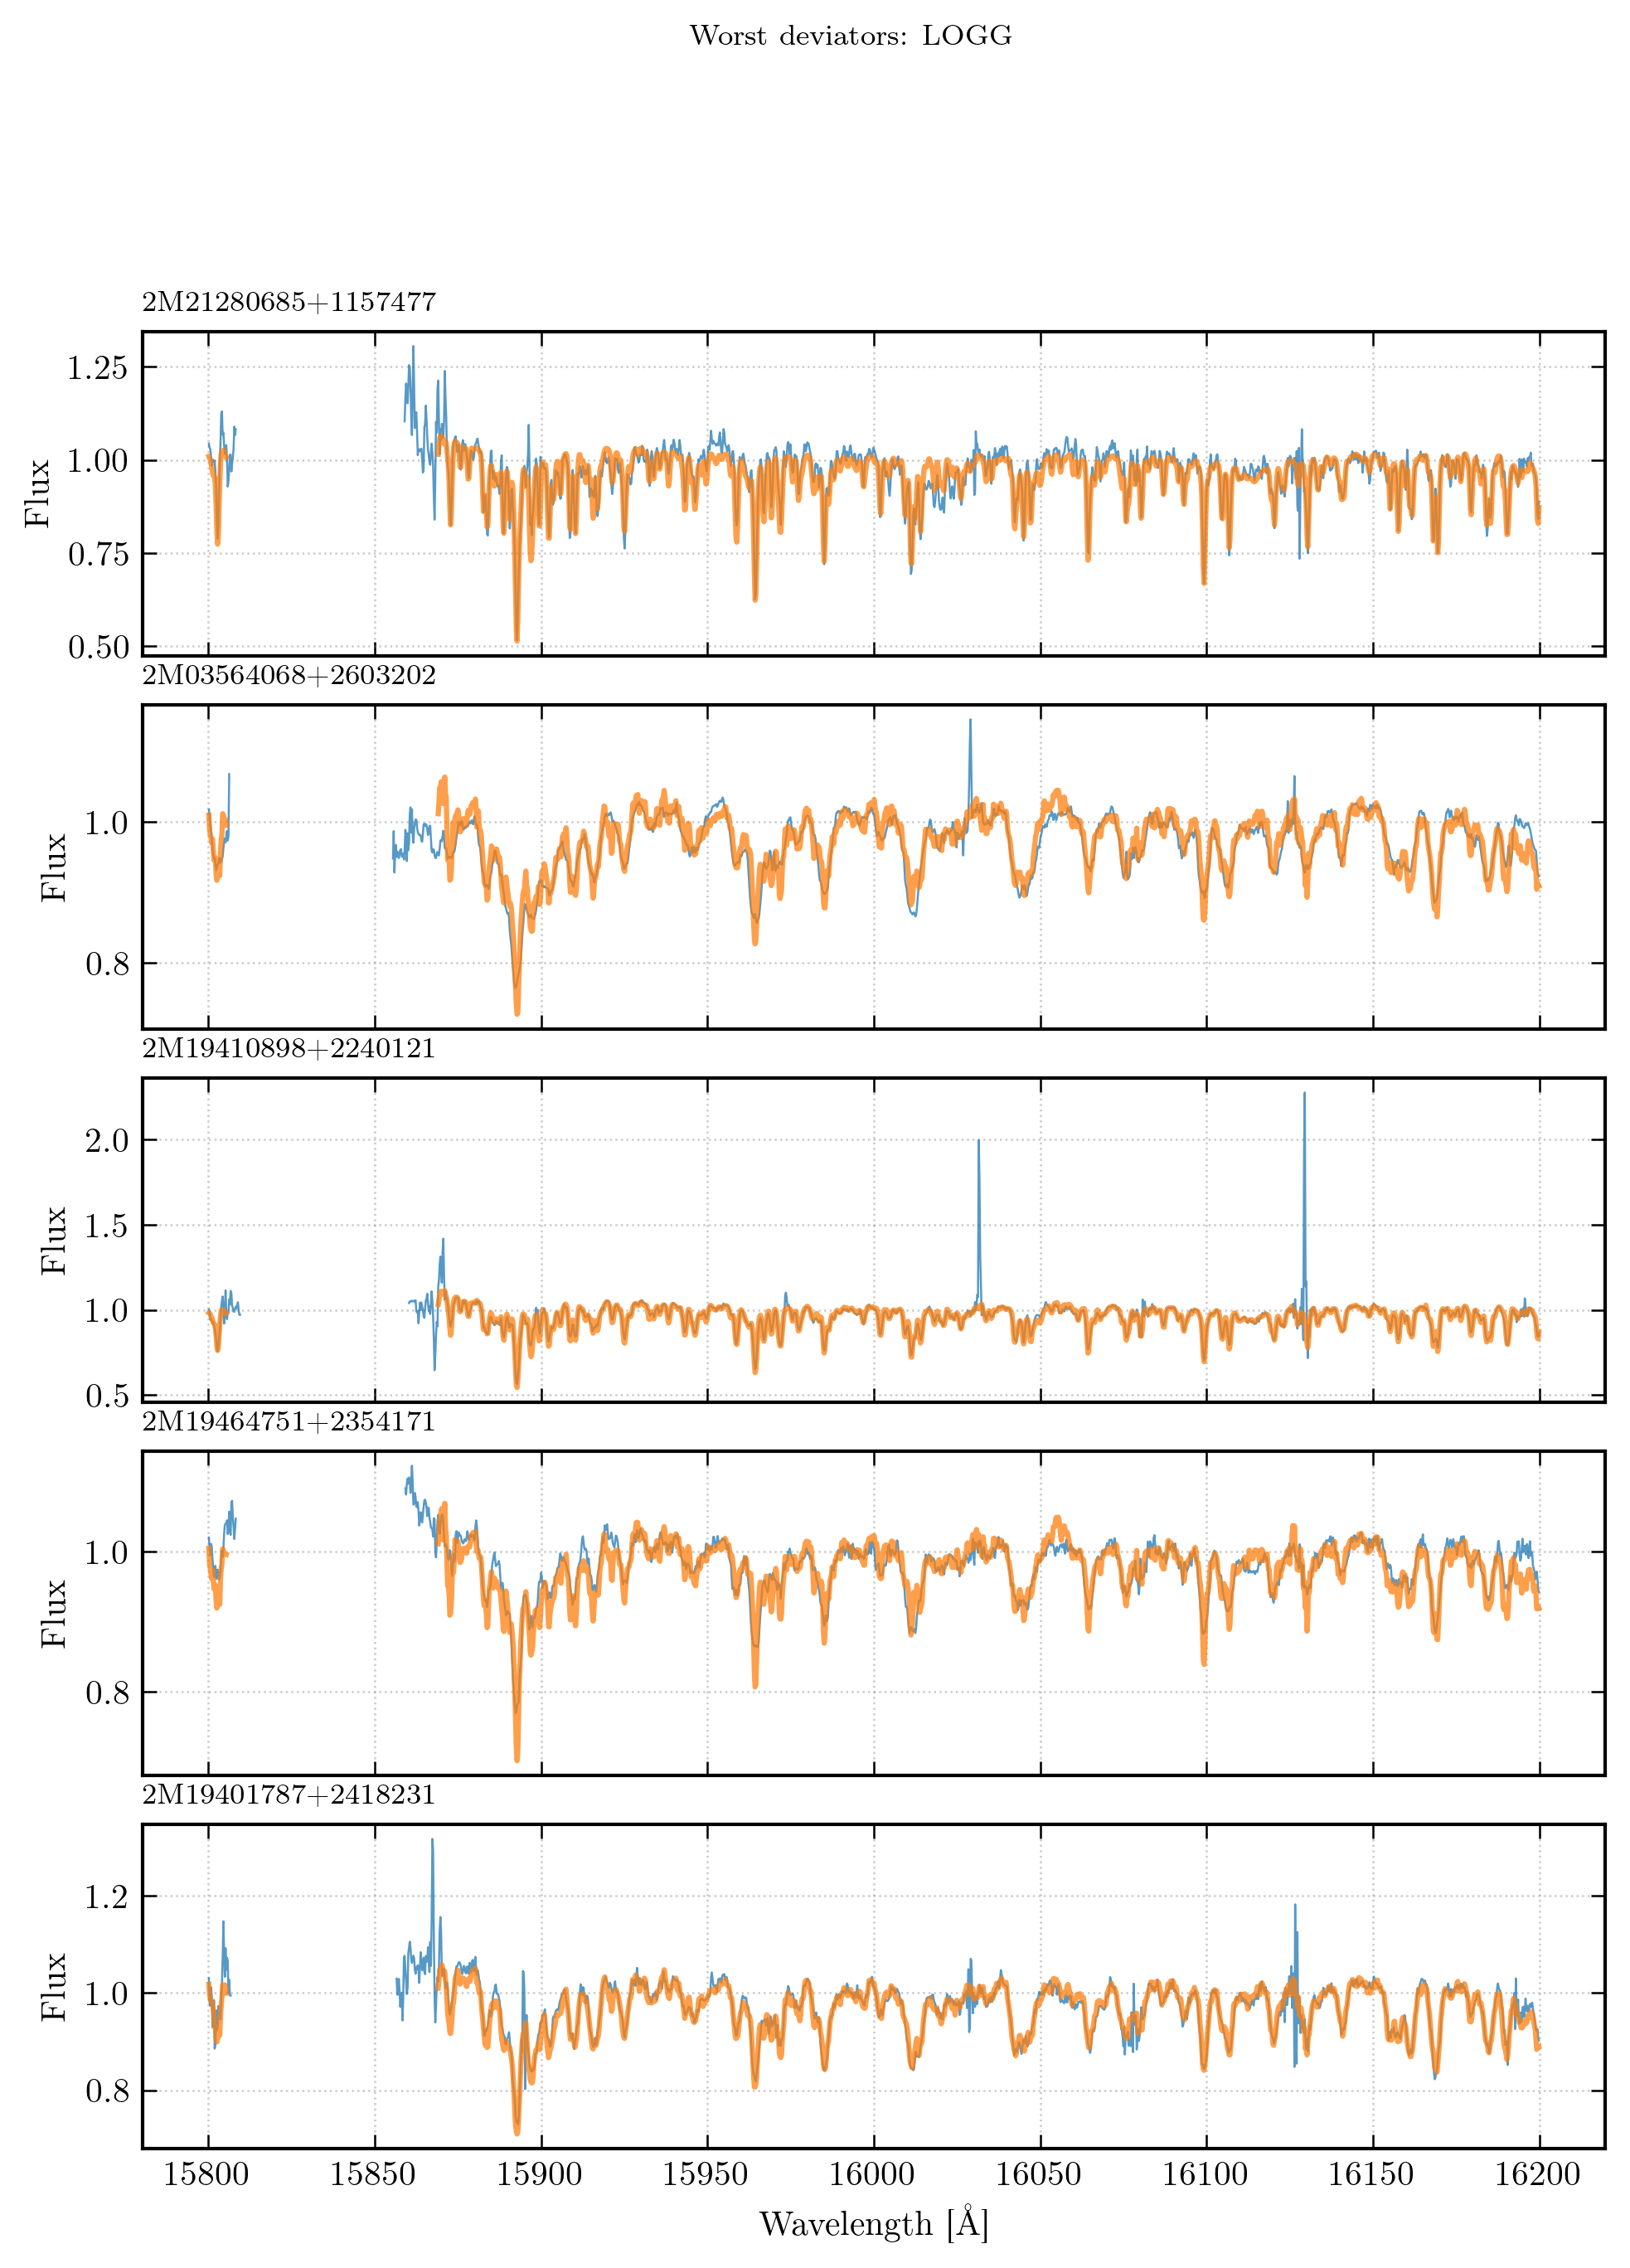

In [12]:
# Worst 5 deviators in logg
i_label = 1
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"Δ={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w, ids_cv[worst5],
    wl_min=15800, wl_max=16200,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in FE_H:
  1. 2M03564068+2603202: true=-0.068, fitted=-0.472, Δ=-0.405
  2. 2M21261328+1139054: true=-0.075, fitted=0.177, Δ=+0.252
  3. 2M03581483+2537118: true=-0.137, fitted=-0.377, Δ=-0.239
  4. 2M19292252+3904095: true=-0.106, fitted=-0.342, Δ=-0.236
  5. 2M19425211+2419119: true=-0.353, fitted=-0.585, Δ=-0.232


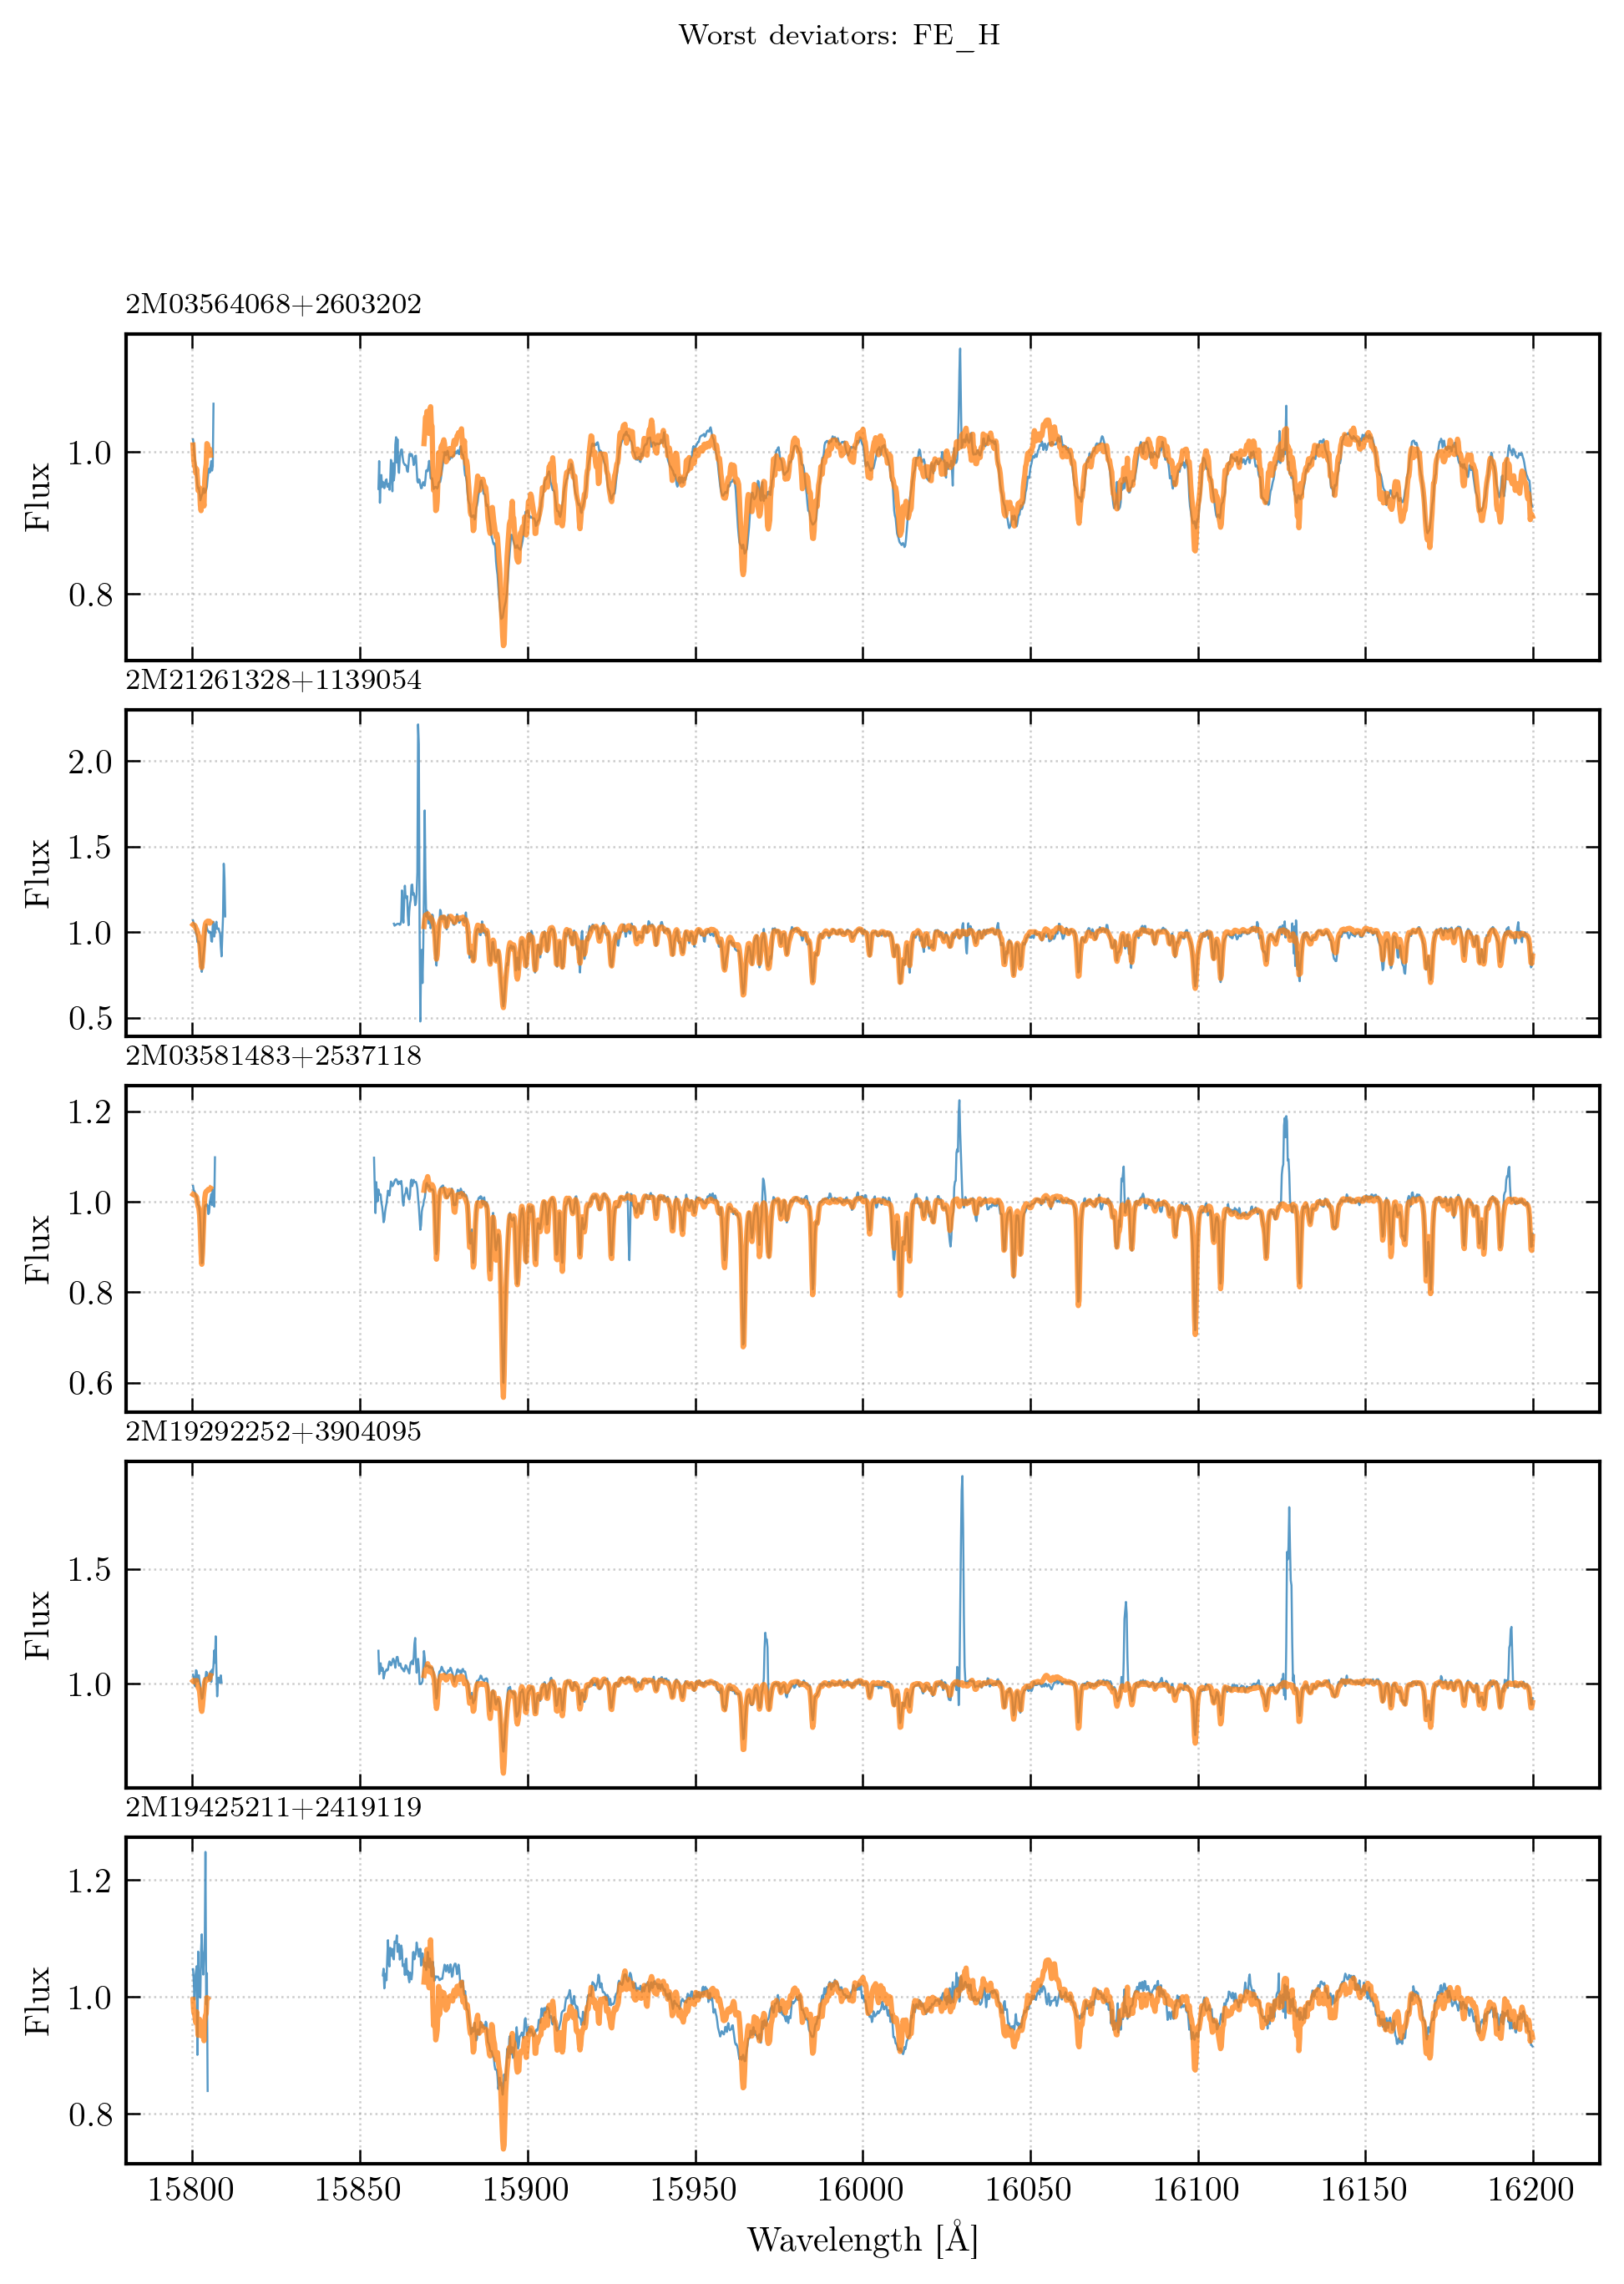

In [13]:
# Worst 5 deviators in [Fe/H]
i_label = 2
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"Δ={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w, ids_cv[worst5],
    wl_min=15800, wl_max=16200,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in MG_FE:
  1. 2M21344249+1214085: true=0.011, fitted=0.339, Δ=+0.328
  2. 2M21281377+1054307: true=0.014, fitted=0.303, Δ=+0.289
  3. 2M19282563+3741232: true=0.299, fitted=0.074, Δ=-0.225
  4. 2M19425211+2419119: true=0.116, fitted=-0.106, Δ=-0.221
  5. 2M19294176+3747402: true=0.098, fitted=-0.098, Δ=-0.196


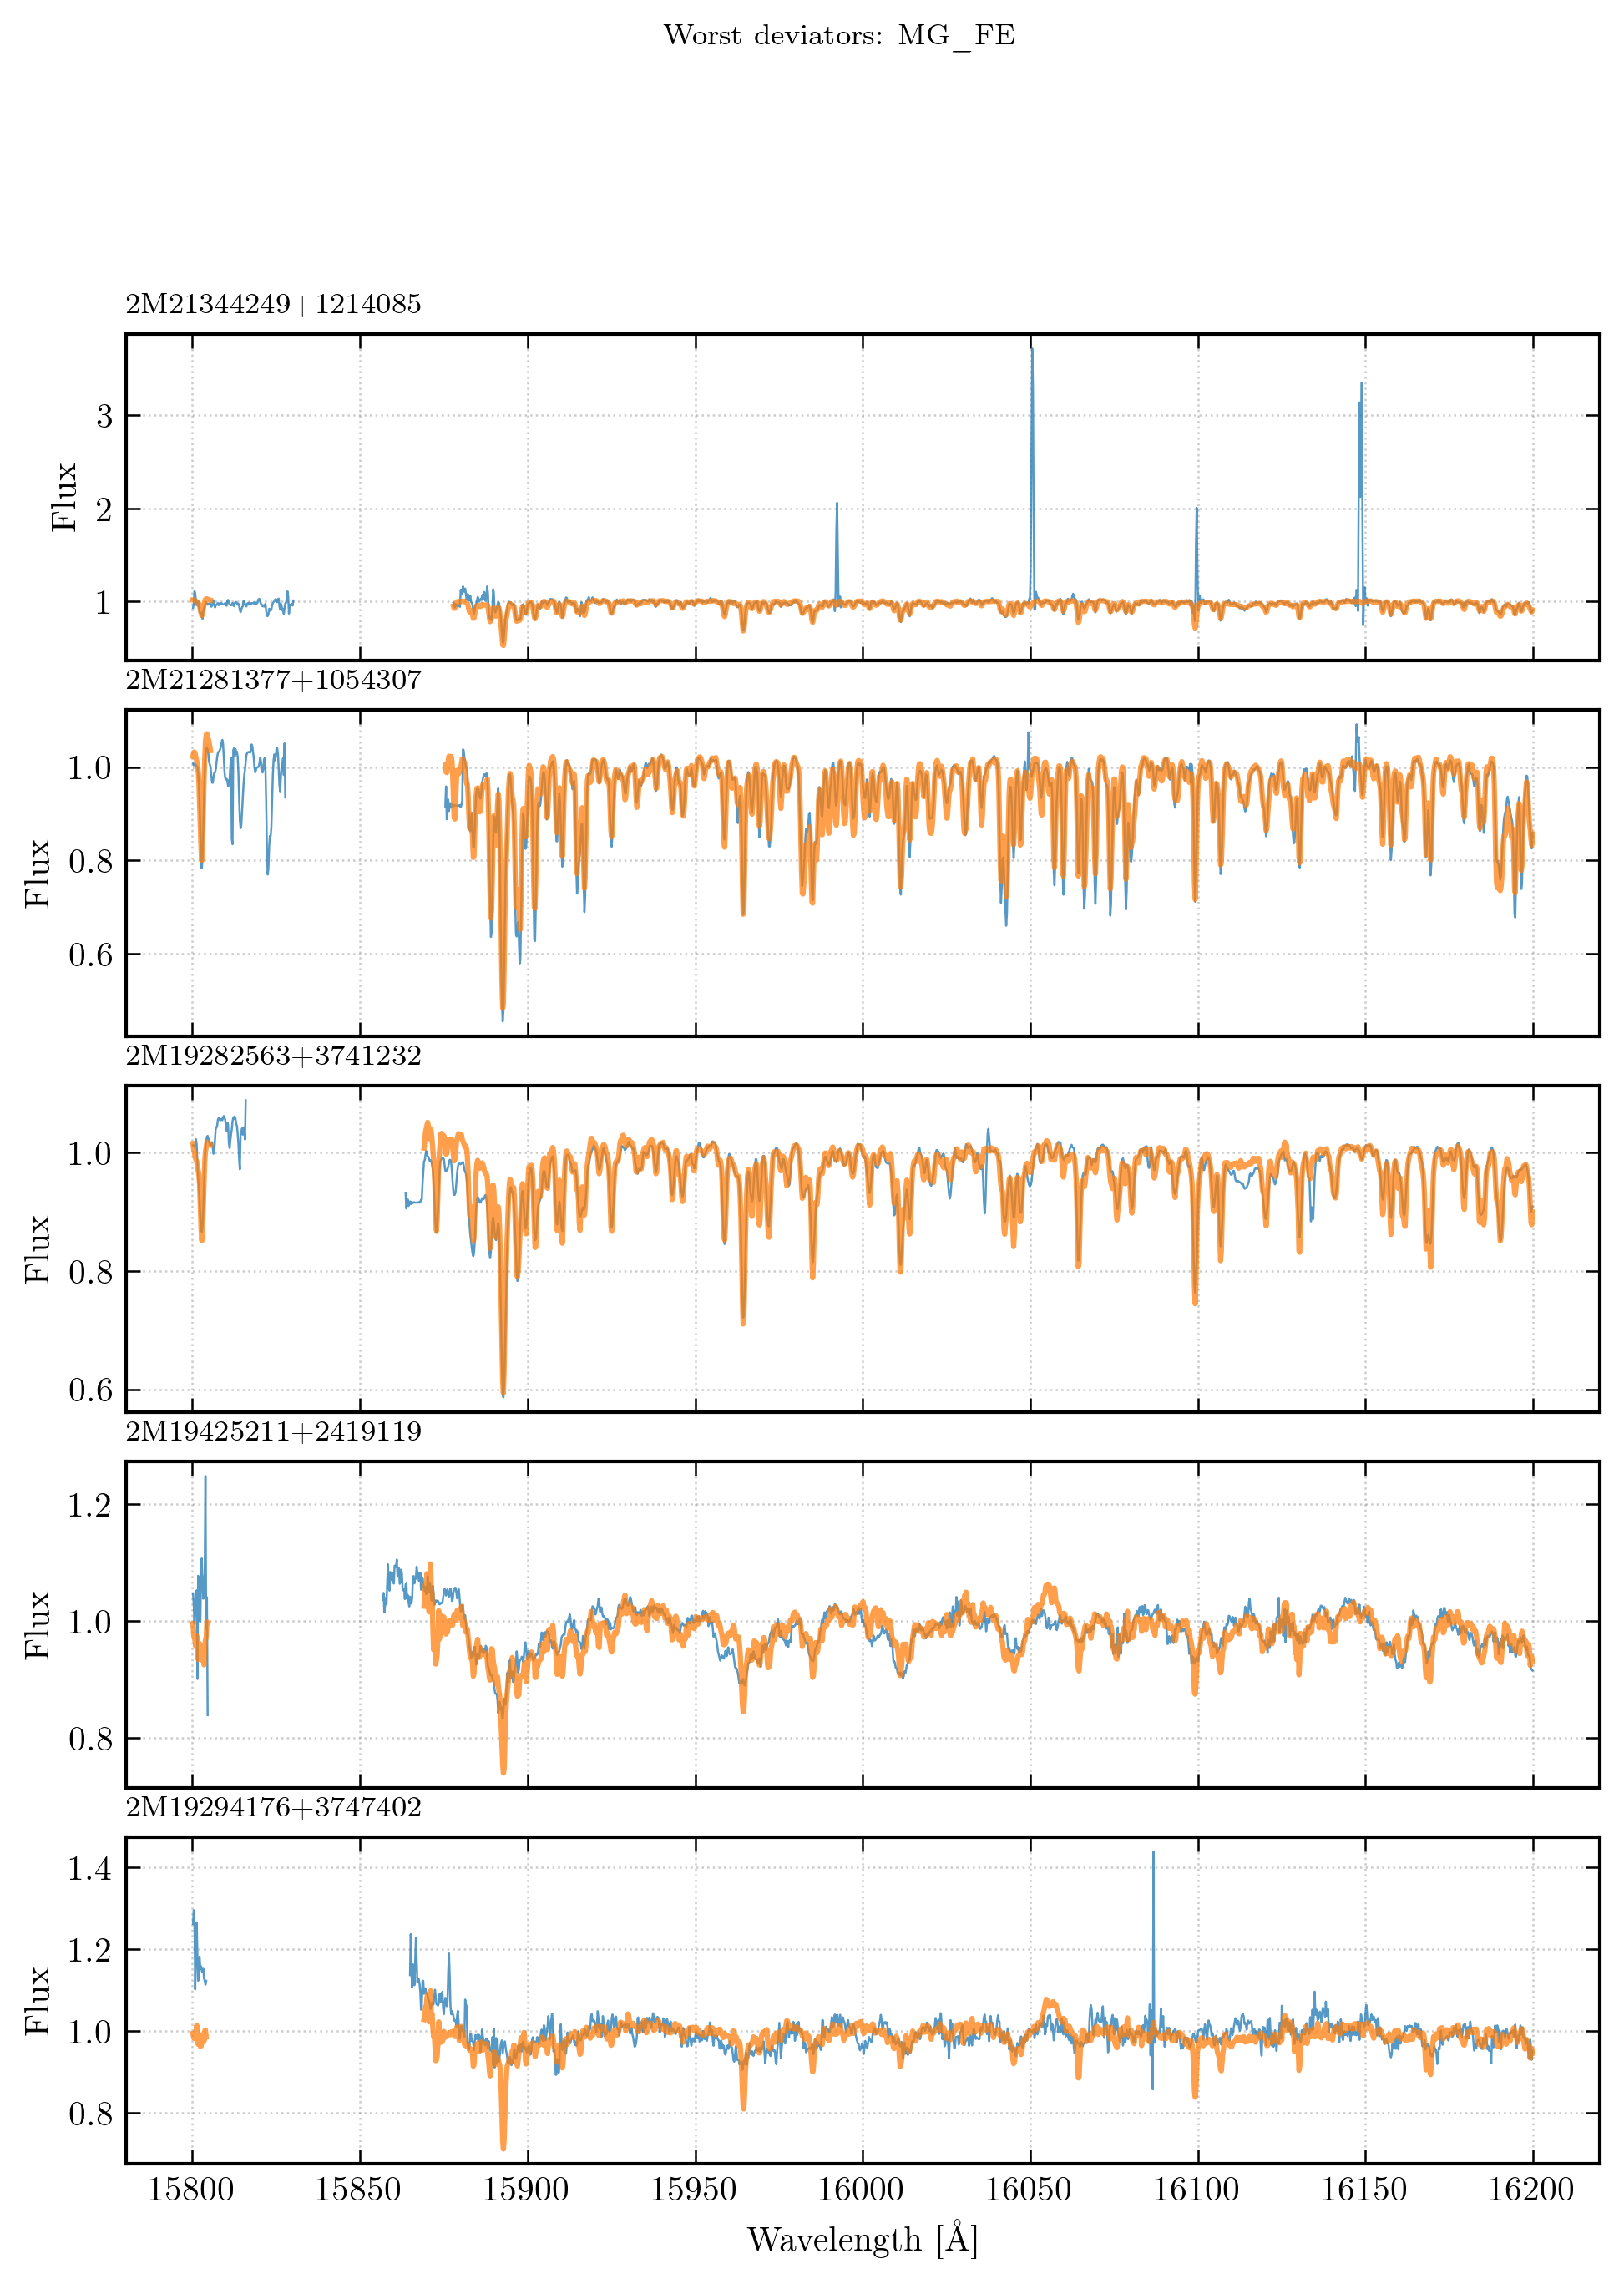

In [14]:
# Worst 5 deviators in [Mg/Fe]
i_label = 3
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"Δ={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w, ids_cv[worst5],
    wl_min=15800, wl_max=16200,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

Worst 5 deviators in SI_FE:
  1. 2M19294176+3747402: true=-0.480, fitted=0.009, Δ=+0.489
  2. 2M19445606+2411079: true=0.146, fitted=-0.121, Δ=-0.266
  3. 2M21281377+1054307: true=0.000, fitted=0.228, Δ=+0.228
  4. 2M19465744+2511396: true=0.040, fitted=-0.150, Δ=-0.190
  5. 2M21344249+1214085: true=0.045, fitted=0.232, Δ=+0.187


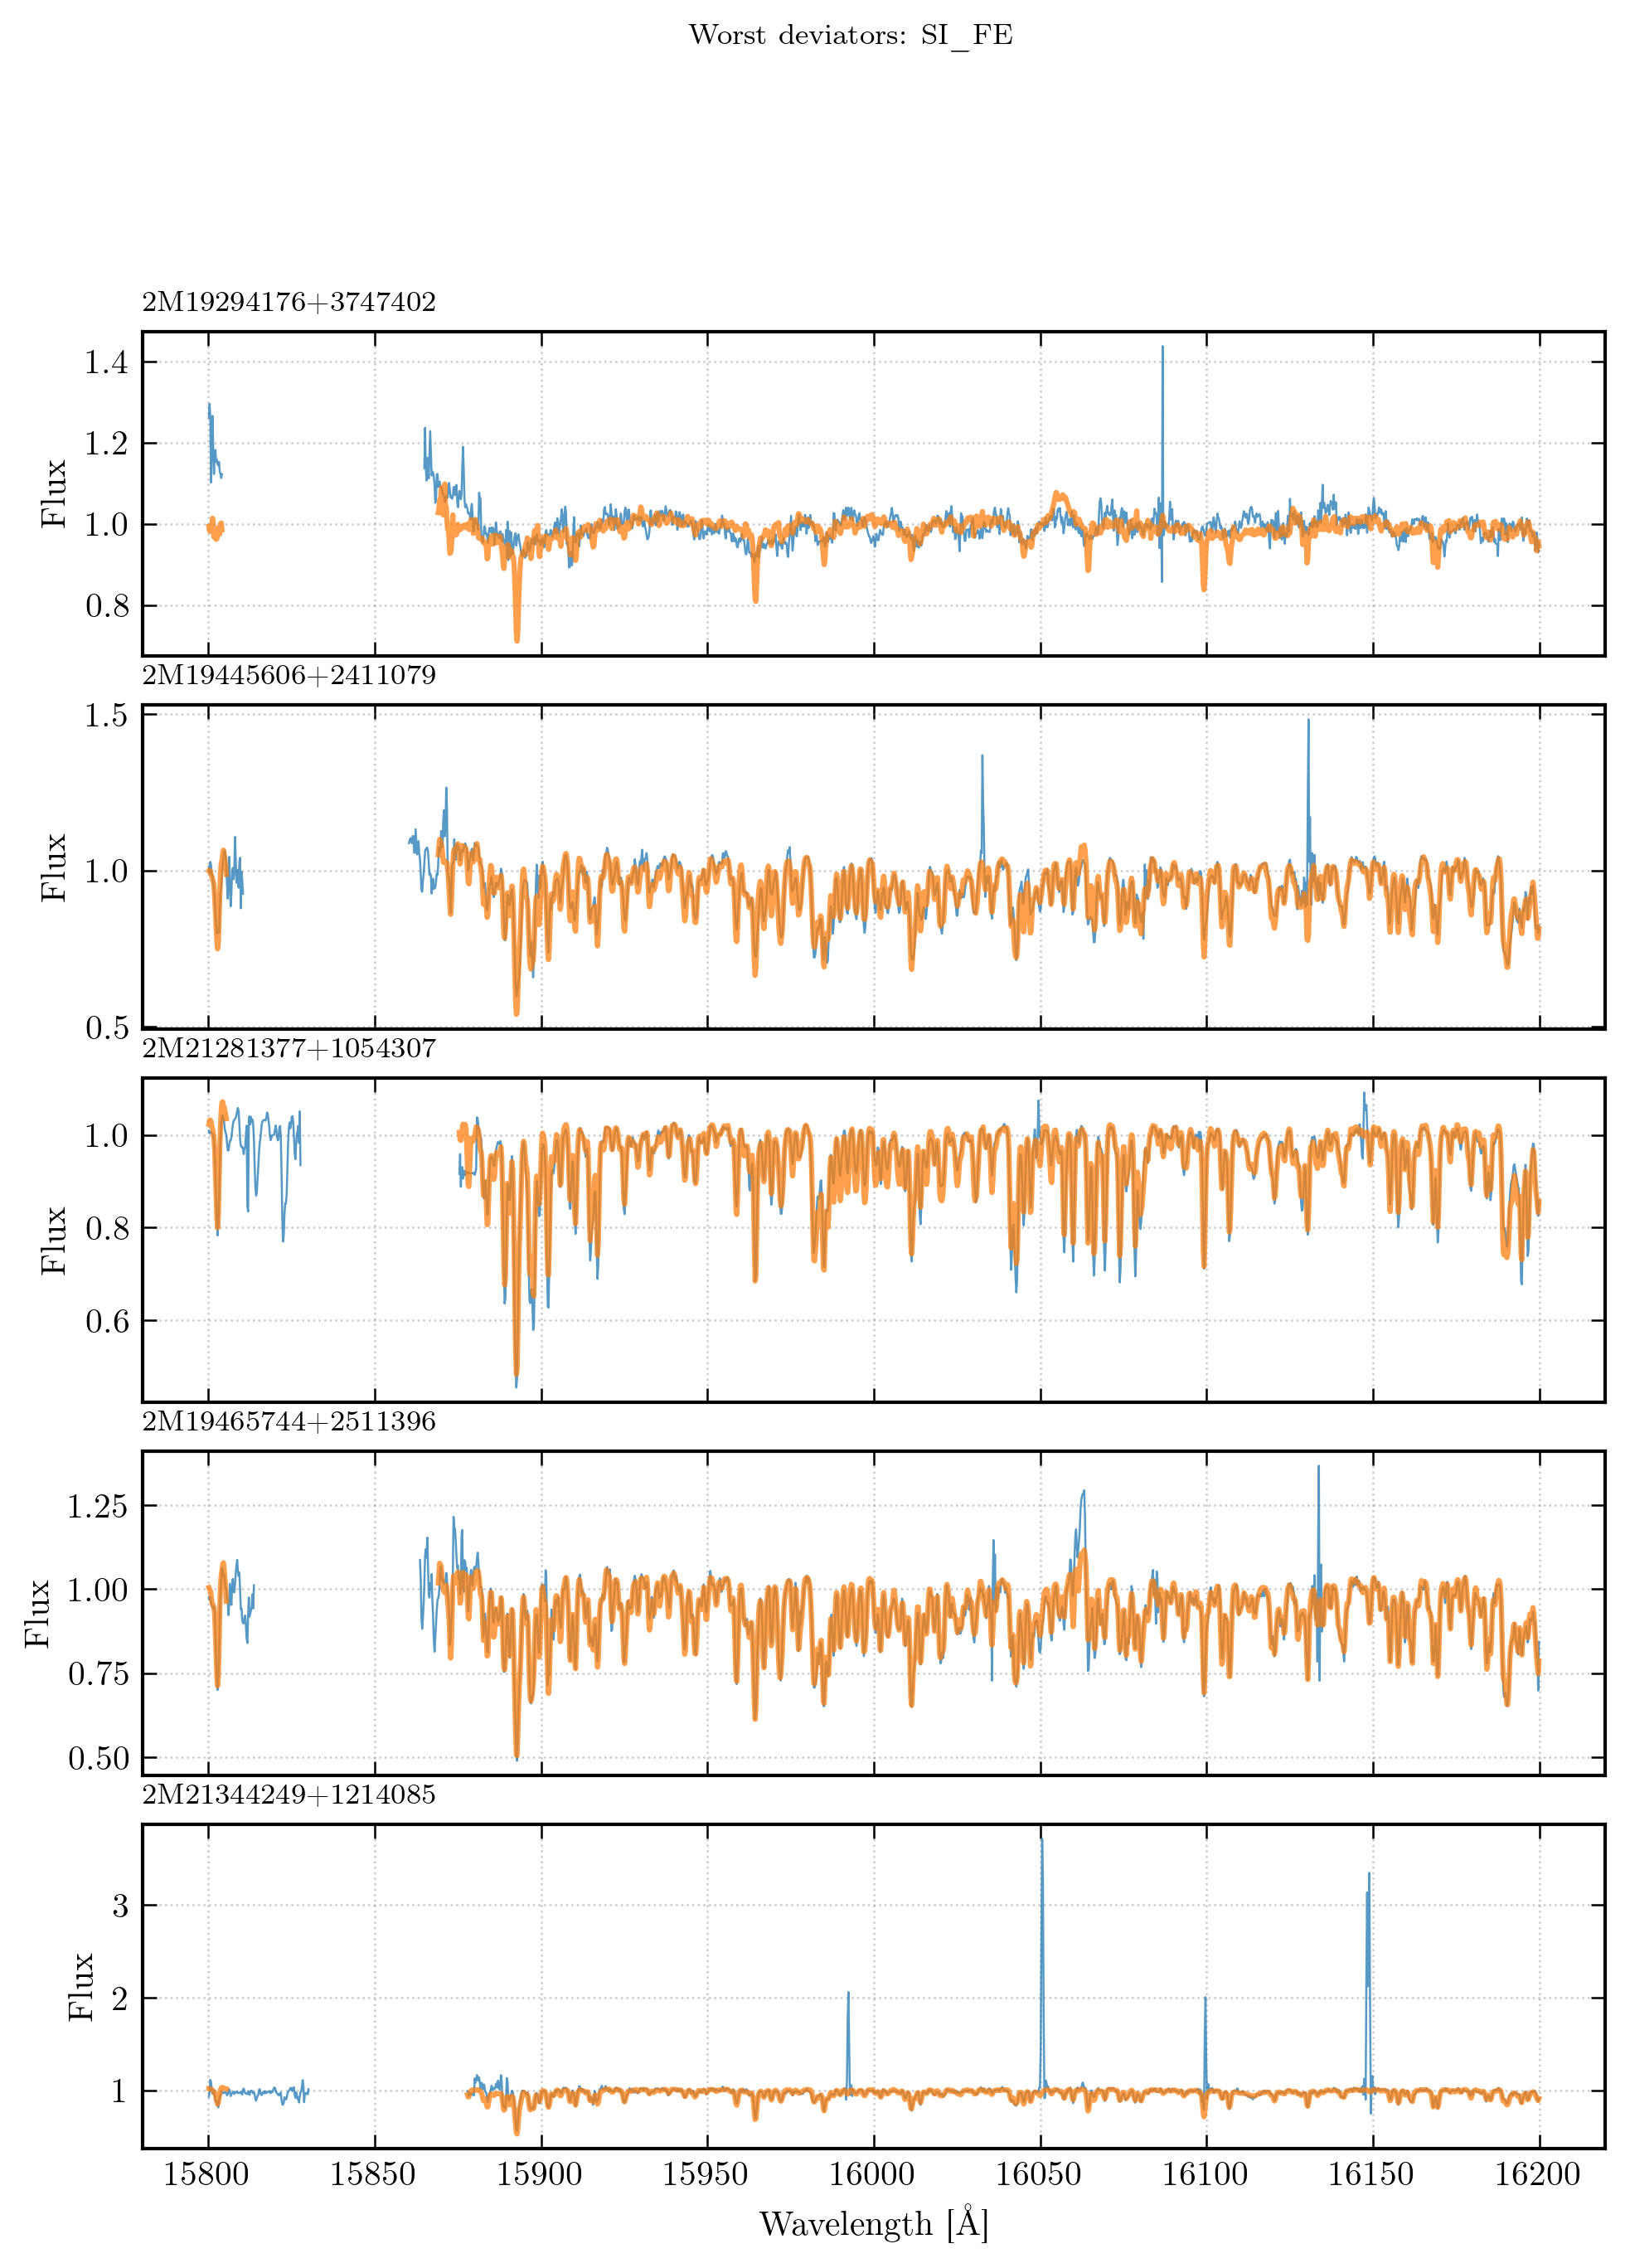

In [15]:
# Worst 5 deviators in [Si/Fe]
i_label = 4
worst5 = np.argsort(np.abs(residuals[:, i_label]))[-5:][::-1]
print(f"Worst 5 deviators in {LABEL_NAMES[i_label]}:")
for rank, idx in enumerate(worst5):
    print(f"  {rank+1}. {ids_cv[idx]}: true={labels_cv[idx, i_label]:.3f}, "
          f"fitted={fitted_labels[idx, i_label]:.3f}, "
          f"Δ={residuals[idx, i_label]:+.3f}")

flux_pred_w = np.array([model.predict(fitted_labels[idx]) for idx in worst5])
axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst5], error_cv[worst5], flux_pred_w, ids_cv[worst5],
    wl_min=15800, wl_max=16200,
)
plt.suptitle(f"Worst deviators: {LABEL_NAMES[i_label]}", y=1.01, fontsize="small")
plt.show()

## Problem 11 — Kiel Diagram

### MIST isochrones

We retrieve **MIST** (MESA Isochrones and Stellar Tracks; Choi et al. 2016) isochrones at $[\mathrm{Fe/H}] = 0$ and $[\mathrm{Fe/H}] = -1$ for an age of 6 Gyr to overlay on the Kiel diagram. Two choices to justify:

- **Why 6 Gyr?** The disk and bulge fields in our training set are dominated by intermediate-age, evolved stars; 6 Gyr is a conventional intermediate age that produces a well-developed RGB and a populated red clump, and is the age that best reproduces the dense red-clump knot we already saw in the training-set Kiel diagram (NB 01). Both M15 (~13 Gyr) and NGC 6791 (~8 Gyr) are older, but isochrone shape on the upper RGB is only weakly age-dependent in this regime, so a 6 Gyr track is an adequate visual reference for *all* of our cluster and field stars.
- **Why MIST?** MIST provides broad coverage of $[\mathrm{Fe/H}]$ on a regular grid with consistent input physics, and is the standard reference grid in the APOGEE community. Padova and BaSTI would give very similar tracks for these regions; the choice is one of convenience rather than physics.


In [ ]:
iso_solar = _get_mist_isochrone(6.0, 0.0)
iso_metal_poor = _get_mist_isochrone(6.0, -1.0)

print(f"[Fe/H]=0 isochrone: {len(iso_solar)} points, "
      f"Teff range {iso_solar['Teff'].min():.0f}–{iso_solar['Teff'].max():.0f} K")
print(f"[Fe/H]=-1 isochrone: {len(iso_metal_poor)} points, "
      f"Teff range {iso_metal_poor['Teff'].min():.0f}–{iso_metal_poor['Teff'].max():.0f} K")

### Kiel diagram

The Kiel diagram ($\log g$ vs $T_{\rm eff}$) reveals evolutionary structure. With both axes inverted (hot→cold left→right, low gravity at top), the red giant branch (RGB) rises from the lower right. The red clump (core He burning) forms a dense concentration near $T_{\rm eff} \sim 4800$ K, $\log g \sim 2.5$. Color-coding by $[\mathrm{Fe/H}]$ shows that metal-rich stars are systematically cooler at fixed $\log g$, consistent with the higher opacity of more metal-rich envelopes (which puffs the star up to a slightly larger radius and a slightly lower surface temperature).

**Comparison to MIST isochrones.** The fitted CV-set Kiel diagram is overlaid with the 6 Gyr MIST isochrones at $[\mathrm{Fe/H}] = 0$ and $-1$. Three things to look at:

1. **Overall RGB shape.** The bulk of the points should follow the curved RGB ridge of the solar-metallicity isochrone from the bottom (warmer subgiants near the cut at $\log g \sim 4$) up to the tip ($\log g \sim 0.5$, $T_{\rm eff} \sim 3600$ K). Visual agreement on the shape confirms that the Cannon's fitted $T_{\rm eff}$ and $\log g$ are physically consistent: a star fit independently from its spectrum lands where stellar evolution says a giant of that metallicity should be.
2. **Red-clump position.** The dense knot of stars at $\log g \approx 2.5$, $T_{\rm eff} \approx 4800$ K should sit very near the analytic red-clump value $\log g \approx 2.08$ derived in NB 01 Problem 3 — within the per-star scatter of $\sim 0.1$ dex in $\log g$. The clump's exact position on the isochrone is age- and metallicity-sensitive, so a slight offset is expected.
3. **Metallicity dependence.** The $[\mathrm{Fe/H}] = -1$ isochrone is shifted to *bluer* (hotter) $T_{\rm eff}$ at fixed $\log g$ than the solar-metallicity isochrone. The metal-poor sub-population in the data (the blue-end of the color scale) should track the metal-poor isochrone more closely than the metal-rich isochrone, and vice versa for the metal-rich tail. If that color-track correspondence holds, it confirms the Cannon has correctly learned the metallicity sensitivity of $T_{\rm eff}$ at fixed $\log g$ — a non-trivial test because $[\mathrm{Fe/H}]$ and $T_{\rm eff}$ are *separately* fit from the spectrum, and only stellar physics (encoded in MIST) connects them.

This is the qualitative version of the Holtzman et al. 2015 comparison: ASPCAP red giants should populate the Kiel diagram in a manner consistent with MIST tracks, and any systematic offset (e.g., the Cannon clump appearing too hot or the metal-poor sequence not following the $[\mathrm{Fe/H}] = -1$ track) would point to a calibration issue with either the spectral model or the input ASPCAP labels.


In [ ]:
isochrone_tracks = [
    (r"MIST $[\mathrm{Fe/H}]=0$", iso_solar),
    (r"MIST $[\mathrm{Fe/H}]=-1$", iso_metal_poor),
]

ax = plotters.plot_kiel_diagram(fitted_labels, isochrone_tracks)
plt.show()

### Save cross-validation results

In [ ]:
# Save CV results from the original model.
# NB 02's cannon_model.npz is authoritative and is NOT overwritten.
np.savez_compressed(
    "cv_results.npz",
    fitted_labels=fitted_labels,
    true_labels=labels_cv,
    apogee_ids_cv=ids_cv,
)
print("Saved cv_results.npz (original model)")
print(f"  fitted_labels: {fitted_labels.shape}")
print(f"  true_labels: {labels_cv.shape}")
